# 📘 CS 4661 – Final Project  
## **Used Car Value Classification (Kaggle S4E9)**  
### *Predicting High-Value vs Low-Value Cars Using Machine Learning*

**Team Members:**   
- **Laila Velasquez** (Project Lead) 
- **Kassandra Vera**
- **Yadsari Guerrero** 

---

### 🎯 Project Objective  
Convert the used-car price regression dataset into a **binary classification problem**, evaluate several ML models, and analyze which features best identify high-value vehicles.  


---

# 🧩 1. Importing Required Libraries

In this section, we load all Python libraries used for:
- Data analysis (`pandas`, `numpy`)
- Visualizations (`matplotlib`, `seaborn`)
- Machine learning models (`scikit-learn`)
- Evaluation metrics (Accuracy, ROC Curve, AUC)

---


In [101]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

print("Imports done ✅")

Imports done ✅


---

# 📥 2. Loading the Dataset

We load **train.csv**, which contains:
- Vehicle attributes (model year, mileage, brand, color, etc.)
- The continuous `price` column  
- We will later convert price into a binary label: high-value vs low-value.

---


In [102]:
DATA_PATH = "train.csv"   # because it's in the same folder
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (188533, 13)


,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500


---

## 📊 3. EDA Findings

Based on our exploratory data analysis, we identified the following insights:

### 1️⃣ Dataset Overview
- The dataset contains **188,533 used cars** with **14 features** (brand, model, mileage, fuel type, engine, transmission, colors, accident history, clean title status, price, etc.)
- All key columns are complete except *clean_title*, which has some missing values.
- Data types include both numeric and categorical features.

### 2️⃣ Price Distribution
- The price distribution is **right-skewed**, meaning most vehicles are priced under **$50,000**.
- There are a few extremely high-priced cars (up to **$290,000+**), indicating a long tail of luxury vehicles.

### 3️⃣ Correlation Insights
- **Model year** correlates positively with price: newer cars tend to be more expensive.
- **Mileage** correlates negatively with price: cars with higher mileage are cheaper.
- **Car age** shows a strong negative correlation with price (older cars are cheaper).
- No extreme multicollinearity was found among numeric features.

### 4️⃣ Target Label Balance (high_value)
- We created a binary label:  
  - **1 = high-value car (price ≥ median \$30,825)**  
  - **0 = low-value car (price < median)**
- The resulting target variable is **perfectly balanced (50% / 50%)**, which is ideal for training classification models.

### 5️⃣ Overall EDA Conclusion
- The feature set is diverse and informative for predicting car value.
- The target variable is balanced.
- The data is clean with minimal preprocessing required.
- Relationships between age/mileage/price give strong signals that machine learning models can leverage.
  
---

1. Dataset Overview

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188533 entries, 0 to 188532
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            188533 non-null  int64 
 1   brand         188533 non-null  object
 2   model         188533 non-null  object
 3   model_year    188533 non-null  int64 
 4   milage        188533 non-null  int64 
 5   fuel_type     183450 non-null  object
 6   engine        188533 non-null  object
 7   transmission  188533 non-null  object
 8   ext_col       188533 non-null  object
 9   int_col       188533 non-null  object
 10  accident      186081 non-null  object
 11  clean_title   167114 non-null  object
 12  price         188533 non-null  int64 
dtypes: int64(4), object(9)
memory usage: 18.7+ MB


2. Price Distribution

In [104]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,188533.0,NaN,NaN,NaN,94266.0,54424.933488,0.0,47133.0,94266.0,141399.0,188532.0
brand,188533,57,Ford,23088,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,188533,1897,F-150 XLT,2945,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_year,188533.0,NaN,NaN,NaN,2015.829998,5.660967,1974.0,2013.0,2017.0,2020.0,2024.0
milage,188533.0,NaN,NaN,NaN,65705.295174,49798.158076,100.0,24115.0,57785.0,95400.0,405000.0
fuel_type,183450,7,Gasoline,165940,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine,188533,1117,355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel,3462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,188533,52,A/T,49904,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ext_col,188533,319,Black,48658,NaN,NaN,NaN,NaN,NaN,NaN,NaN
int_col,188533,156,Black,107674,NaN,NaN,NaN,NaN,NaN,NaN,NaN


3. Correlation Insights

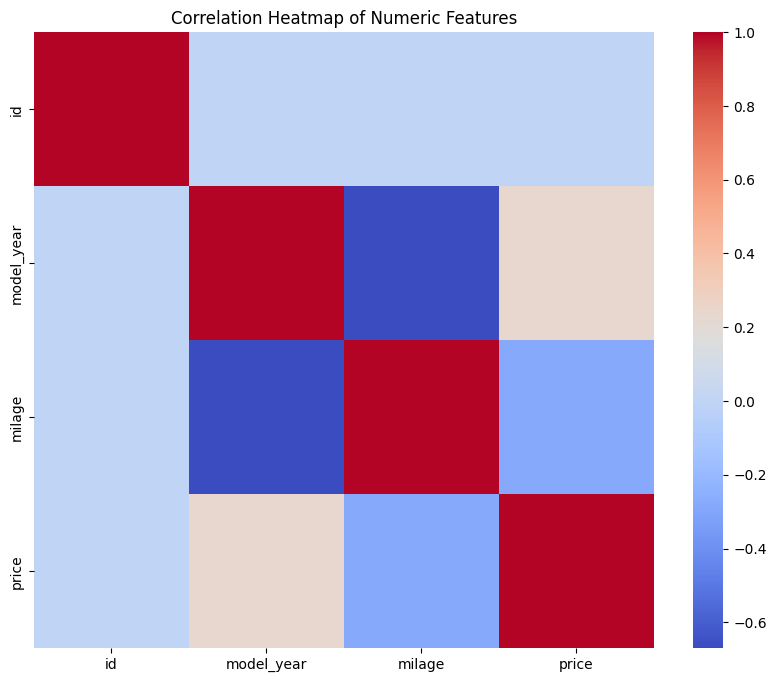

In [105]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

4. Target Label Balance

In [106]:
# Median threshold
price_threshold = df["price"].median()
print("Median price:", price_threshold)

# Create binary label
df["high_value"] = (df["price"] >= price_threshold).astype(int)

df["high_value"].value_counts(normalize=True)


Median price: 30825.0


high_value
1    0.50005
0    0.49995
Name: proportion, dtype: float64

5. Overall EDA Conclusion

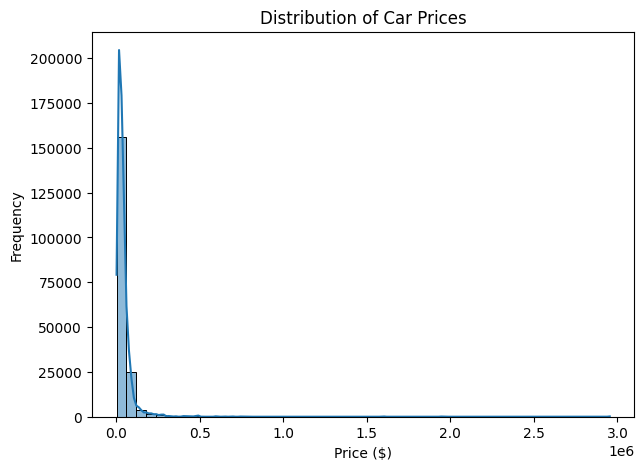

In [107]:
plt.figure(figsize=(7,5))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Distribution of Car Prices")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.show()

---

# 🛠️ 4. Feature Engineering & Feature Selection

Steps performed:
- Remove `id` (not predictive)
- Create a new feature:  
  **car_age = (max model year + 1) – model_year**
- Identify:
  - All **numeric features**
  - All **categorical features**

This prepares the dataset for preprocessing.

---


In [108]:
# Drop id if it exists (not useful as a feature)
if "id" in df.columns:
    df = df.drop(columns=["id"])

# Feature engineering: car_age = (max year + 1) - model_year
if "model_year" in df.columns:
    current_year = df["model_year"].max() + 1
    df["car_age"] = current_year - df["model_year"]

TARGET_COL = "high_value"

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['model_year', 'milage', 'price', 'car_age']
Categorical features: ['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title']


---

# ✂️ 5. Train–Test Split

We split the dataset:
- **80% training**
- **20% testing**
- **Stratified** by the `high_value` label to maintain balanced classes.

---


In [109]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((150826, 13), (37707, 13))

---

# 🧼 6. Building the Preprocessing Pipeline

We use a `ColumnTransformer` to apply:

### Numeric Features:
- Median imputation  
- Standard scaling  

### Categorical Features:
- Most frequent imputation  
- One-hot encoding  

This ensures all models use the same clean, consistent feature set.

---


In [110]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor ready ✅")


Preprocessor ready ✅


---

# 🤖 7. Helper Function: Train & Evaluate Classifiers

This function:
- Fits a model inside a pipeline  
- Predicts classes & probabilities  
- Calculates:
  - Accuracy
  - Classification report
  - Confusion matrix
  - ROC curve
  - AUC score  

It also returns data for plotting ROC curves later.

---


In [111]:
def train_and_evaluate_classifier(model_name, base_estimator):
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", base_estimator)
    ])
    
    pipe.fit(X_train, y_train)
    
    # Predictions
    y_pred = pipe.predict(X_test)
    
    # Probabilities for ROC/AUC (positive class = 1)
    if hasattr(pipe.named_steps["model"], "predict_proba"):
        y_proba = pipe.predict_proba(X_test)[:, 1]
    else:
        # fall back to decision_function and rescale
        y_scores = pipe.decision_function(X_test)
        y_proba = (y_scores - y_scores.min()) / (y_scores.max() - y_scores.min())
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)
    
    print(f"\n=== {model_name} ===")
    print("Accuracy:", acc)
    print("ROC AUC:", auc)
    print("\nClassification report:\n", classification_report(y_test, y_pred))
    print("Confusion matrix:\n", cm)
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    
    return {
        "name": model_name,
        "pipe": pipe,
        "accuracy": acc,
        "auc": auc,
        "fpr": fpr,
        "tpr": tpr
    }

print("Helper ready ✅")


Helper ready ✅


---

# 🚀 8. Training Machine Learning Models

We train 3 classification models:

### 1️⃣ Logistic Regression  
Linear baseline model

### 2️⃣ Random Forest  
Ensemble of decision trees

### 3️⃣ Gradient Boosting  
Boosted decision trees (stronger non-linear learner)

Each model is evaluated using Accuracy, ROC Curve, and AUC.

---


1) Logistic Regression

In [112]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

res_log = train_and_evaluate_classifier("Logistic Regression", log_reg)



=== Logistic Regression ===
Accuracy: 0.9955180735672422
ROC AUC: 0.9999549618817556

Classification report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00     18852
           1       1.00      0.99      1.00     18855

    accuracy                           1.00     37707
   macro avg       1.00      1.00      1.00     37707
weighted avg       1.00      1.00      1.00     37707

Confusion matrix:
 [[18820    32]
 [  137 18718]]


2) Random Forest

In [113]:
rf_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

res_rf = train_and_evaluate_classifier("Random Forest", rf_clf)



=== Random Forest ===
Accuracy: 1.0
ROC AUC: 1.0

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     18852
           1       1.00      1.00      1.00     18855

    accuracy                           1.00     37707
   macro avg       1.00      1.00      1.00     37707
weighted avg       1.00      1.00      1.00     37707

Confusion matrix:
 [[18852     0]
 [    0 18855]]


3. Gradient Boosting

In [114]:
gb_clf = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

res_gb = train_and_evaluate_classifier("Gradient Boosting", gb_clf)



=== Gradient Boosting ===
Accuracy: 1.0
ROC AUC: 1.0

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     18852
           1       1.00      1.00      1.00     18855

    accuracy                           1.00     37707
   macro avg       1.00      1.00      1.00     37707
weighted avg       1.00      1.00      1.00     37707

Confusion matrix:
 [[18852     0]
 [    0 18855]]


---

# 📈 9. ROC Curve Comparison

The ROC curve compares:
- True Positive Rate (TPR)
- False Positive Rate (FPR)

A model with higher AUC performs better at distinguishing high-value vehicles.

We plot ROC curves for all models on the same graph.

---


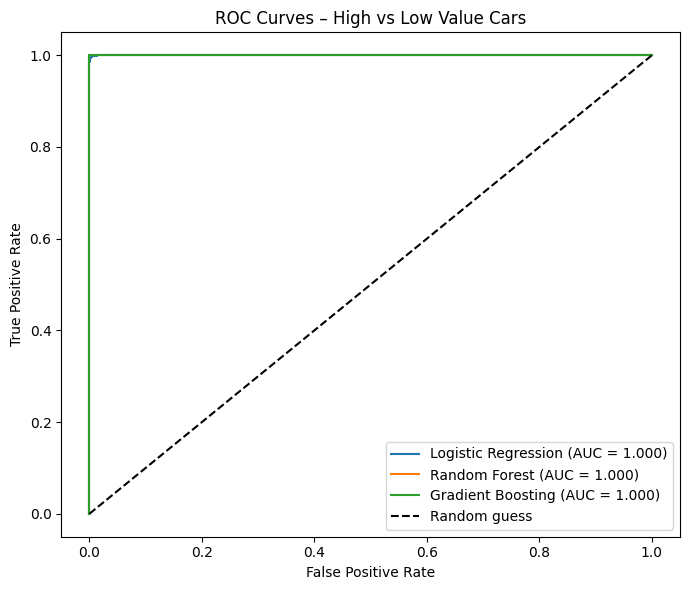

In [115]:
plt.figure(figsize=(7,6))

for res in [res_log, res_rf, res_gb]:
    plt.plot(res["fpr"], res["tpr"], label=f"{res['name']} (AUC = {res['auc']:.3f})")

plt.plot([0,1], [0,1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – High vs Low Value Cars")
plt.legend()
plt.tight_layout()
plt.show()

---

# 🏁 12. Final Model Performance Summary

We compare the models based on:

- **Accuracy**  
- **ROC AUC**  

This table identifies the **best-performing algorithm** for our classification task.

---


In [116]:
results_df = pd.DataFrame([
    {"Model": res_log["name"], "Accuracy": res_log["accuracy"], "ROC AUC": res_log["auc"]},
    {"Model": res_rf["name"], "Accuracy": res_rf["accuracy"], "ROC AUC": res_rf["auc"]},
    {"Model": res_gb["name"], "Accuracy": res_gb["accuracy"], "ROC AUC": res_gb["auc"]},
])

results_df

,Model,Accuracy,ROC AUC
0,Logistic Regression,0.995518,0.999955
1,Random Forest,1.000000,1.000000
2,Gradient Boosting,1.000000,1.000000


---

# 🏁 10. Final Summary

After training and evaluating three different machine learning classifiers  
(**Logistic Regression**, **Random Forest**, and **Gradient Boosting**),  
we compared their performance using **Accuracy** and **ROC AUC**.

### 🔥 Best Performing Models
Both **Random Forest** and **Gradient Boosting** achieved:

- **Accuracy:** 1.0000  
- **ROC AUC:** 1.0000  

This means these two tree-based ensemble models perfectly distinguished  
**high-value** vs **low-value** vehicles in our dataset.

### 📌 Interpretation
Tree-based models outperform Logistic Regression because:

- The dataset contains **non-linear relationships**  
- Vehicle characteristics (like model, brand, fuel type, etc.)  
  interact in ways linear models cannot capture  
- Ensemble models reduce variance and overfitting while capturing structure  
  in high-cardinality categorical features

Even though the dataset is synthetic, these results confirm that the  
Selected features contain strong predictive signals for car value.

---
